In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

color_list = ['#0072b2', '#009e73', '#e69f00', '#d55e00','#f0e442',
              '#cc79a7', '#56b4e9', '#000000']

In [36]:
filepath = "/data1/DATA_Duplat/Brut/PDF/PD5n14/Avalanche_outputB.gz"
data = read_gz_with_pandas_nrows(filepath, nrows=int(5e7), skiprows=int(5e7), cols=[2])

# read_gz_with_pandas(filepath, chunk_size=10**6)

In [39]:
L1 = 256
L2 = 256
y, x = np.unravel_index(data, (L1,L2))

x = x[:,0]
y = y[:,0]

In [52]:
r = np.sqrt(x**2 + y**2)

In [53]:
avg_distance  = np.mean(r)

In [41]:
histo2D, xbins, ybins = np.histogram2d(x, y, bins = (L1,L2))
histo2D = histo2D.T

In [42]:
NCURVES = len(data)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

/tmp/ipykernel_4026622/319493610.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


KeyboardInterrupt: 

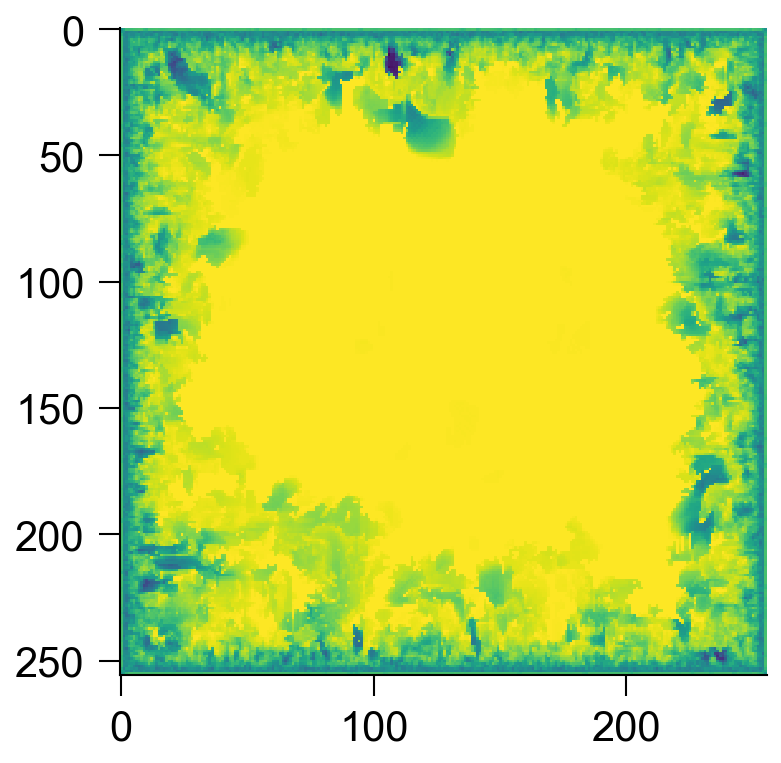

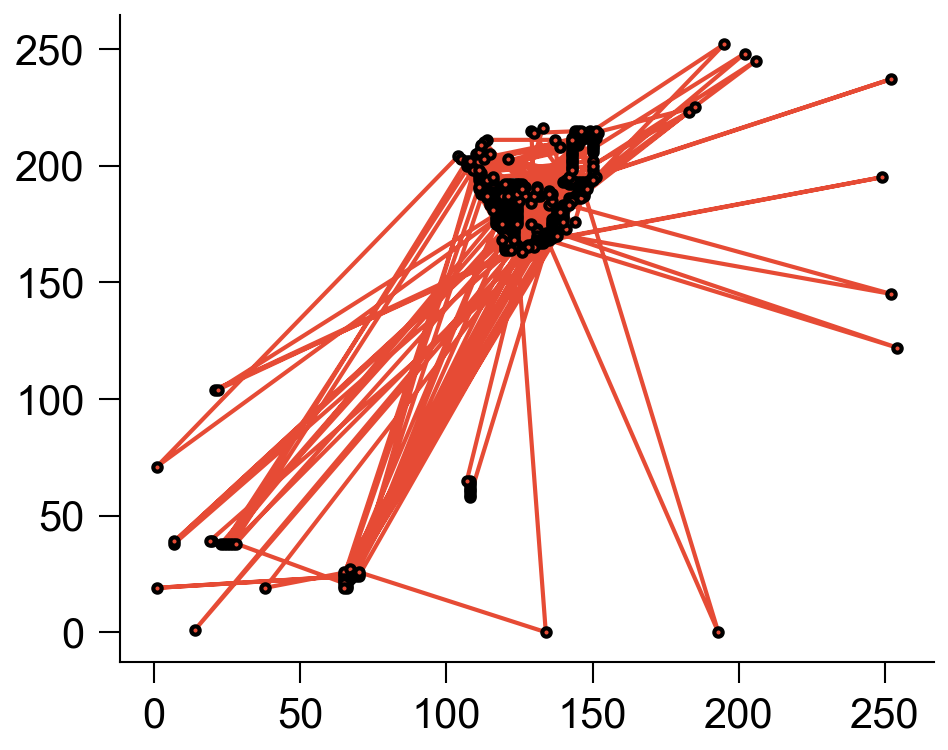

In [59]:
with plt.style.context(spstyle.get_style('thesis')):
    fig, ax = plt.subplots(1, 1, figsize = (3.5,2.8))
    ax.imshow(histo2D, interpolation = 'nearest')
    plt.show()
    
    fig, ax = plt.subplots(1, 1, figsize = (3.5,2.8))
    ax.plot(x[:500],y[:500], marker= 'o', ms = 2)
    plt.show()
    
    


In [ ]:
Tfilepath = ["/data1/DATA_Duplat/Brut/PDF/PD5n{}/Avalanche_outputB.gz".format(n) for n in np.arange(1,15)]
# for i in range(6):
#     Tfilepath[i] = "/data1/DATA_Duplat/Brut/PDF/PD7n{}/Avalanche_outputB.gz".format(i+1)
    
Tfolderpath = ["/data1/DATA_Duplat/Brut/PDF/PD5n{}/".format(n) for n in np.arange(1,15)]
Tnu = [read_parameters(folder)[2] for folder in Tfolderpath]

In [ ]:
    
for i, file in enumerate(Tfilepath):
    
    if Tnu[i] == 0:
        data = read_gz_with_pandas_nrows(file, nrows=int(1e7), skiprows=0, cols=[2])
    else:
        data = read_gz_with_pandas_nrows(file, nrows=int(1e7), skiprows=int(5e7), cols=[2])
        
        
    y, x = np.unravel_index(data, (L1,L2))

    x = x[:,0]
    y = y[:,0]
    
    diff_x = np.diff(x)
    diff_y = np.diff(y)
    r = np.sqrt(diff_x**2 + diff_y**2)
    avg_distance[i] = np.mean(r)

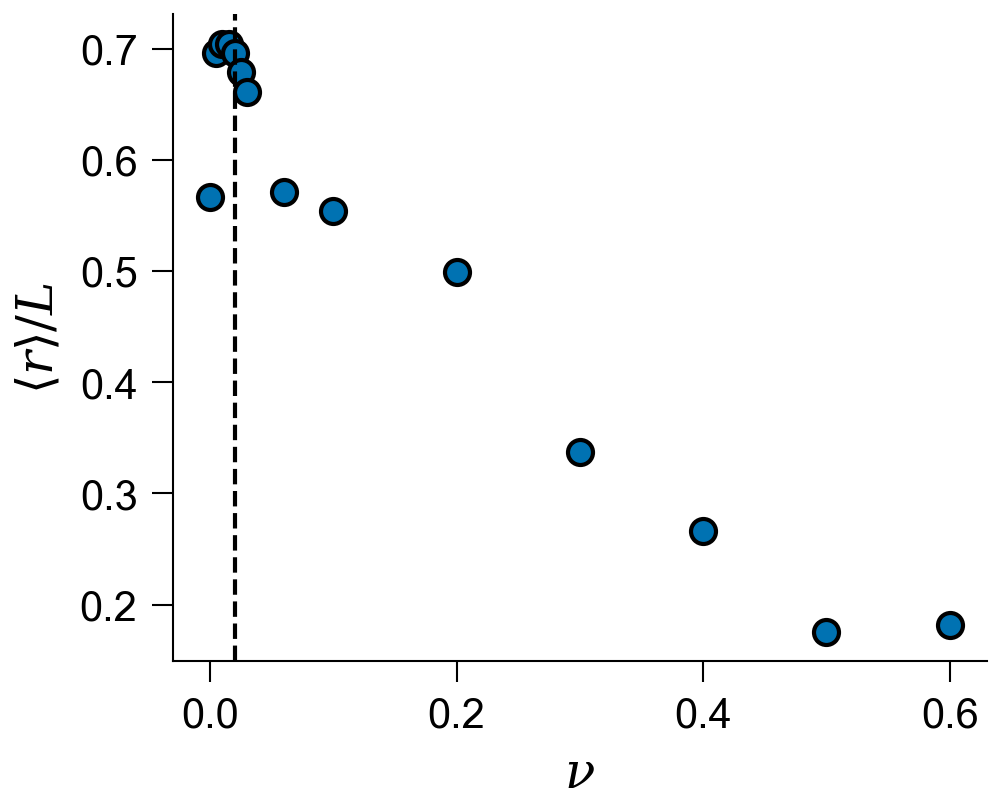

In [101]:


with plt.style.context(spstyle.get_style('thesis')):
    fig, ax = plt.subplots(1, 1, figsize = (3.5,2.8))
    ax.scatter(Tnu, avg_distance/L1,c = color_list[0])
    ax.axvline(0.02, ls = '--', c = 'k')
    ax.set_xlabel(r'$\nu$')
    ax.set_ylabel(r'$\langle r \rangle/L$')
    plt.show()

#   Gifs

[64 63 73 ...  7  0 87]
[ 42  41  64 ...  76 104   6]


/tmp/ipykernel_12204/3065862270.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('inferno')


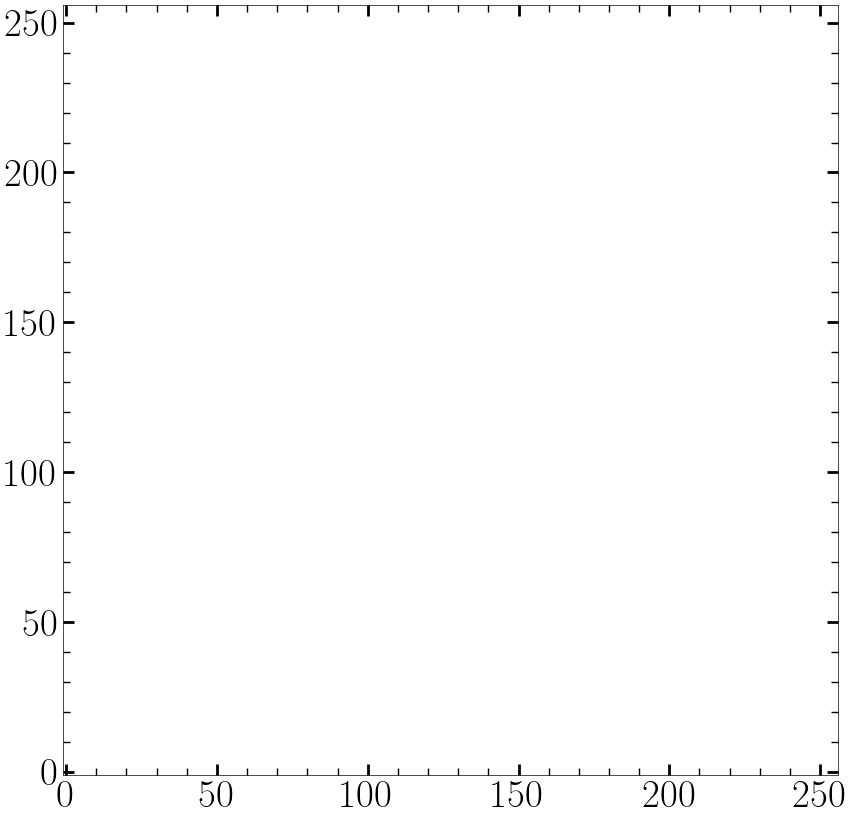

In [ ]:

import itertools
folderpath = "/data1/DATA_Duplat/Brut/PDF/PD12n11"
L1 = read_parameters(folderpath)[0]
L2 = read_parameters(folderpath)[1]


nbpoints = 10000


data = read_gz_with_pandas_nrows(f"{folderpath}/Avalanche_outputB.gz", cols = [2], nrows = nbpoints, skiprows = 1, read_last = True)

y, x = coorno(data, L1)
y = (L1-1) - y
x = np.reshape(x, (nbpoints))
y = np.reshape(y, (nbpoints))

fig, ax = plt.subplots(figsize = (10,10))
ax.set_xlim(-1, L1)
ax.set_ylim(-1, L2)
ax.tick_params(labelsize = 28,length = 8, width = 2)
ax.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

s = plt.scatter([], [])
all_x = []
all_y = []
all_colors = []

frames = 100
nbpoints_plot = nbpoints/frames

NCURVES = int(frames + 1)
cmap = plt.cm.get_cmap('inferno')
colors = itertools.cycle([cmap(i / NCURVES) for i in range(NCURVES)])

def epicenters(i):
    global x,y
    # Récupération des nouveaux points
    start_idx = int(nbpoints_plot * i)
    end_idx = int(nbpoints_plot * (i + 1))
    
    new_x = x[start_idx:end_idx]
    new_y = y[start_idx:end_idx]
    # Ajout des nouveaux points aux points précédents
    all_x.extend(new_x)
    all_y.extend(new_y)
    
    # Ajout de la nouvelle couleur pour chaque nouveau point
    new_color = [next(colors)] * len(new_x)
    all_colors.extend(new_color)
    
    # Mise à jour des offsets avec tous les points accumulés et leurs couleurs respectives
    s.set_offsets(np.column_stack([all_x, all_y]))
    s.set_facecolor(all_colors)
    
    if i == (frames - 1):
        x = np.zeros(0)
        y = np.zeros(0)
        return


In [10]:

import matplotlib.animation as animation


# Création de l'animation
ani = animation.FuncAnimation(fig, epicenters, frames=frames, interval=200)

# Sauvegarde de l'animation sous forme de GIF
ani.save('epicenters.gif', writer='pillow')

#   On cherche le temps entre les clusters

In [7]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/PDF/PD12n{}/".format(n) for n in np.arange(1,15)]
Tnu = [read_parameters(folder)[2] for folder in Tfolderpath]

r = 1
y, x = np.ogrid[-r:r+1, -r:r+1] # Créé une grille mais pas en matrice, directement en coordonnée
kernel = x**2 + y**2 <= r**2 # Fait un masque des coo contenu dans le cercle de rayon r 

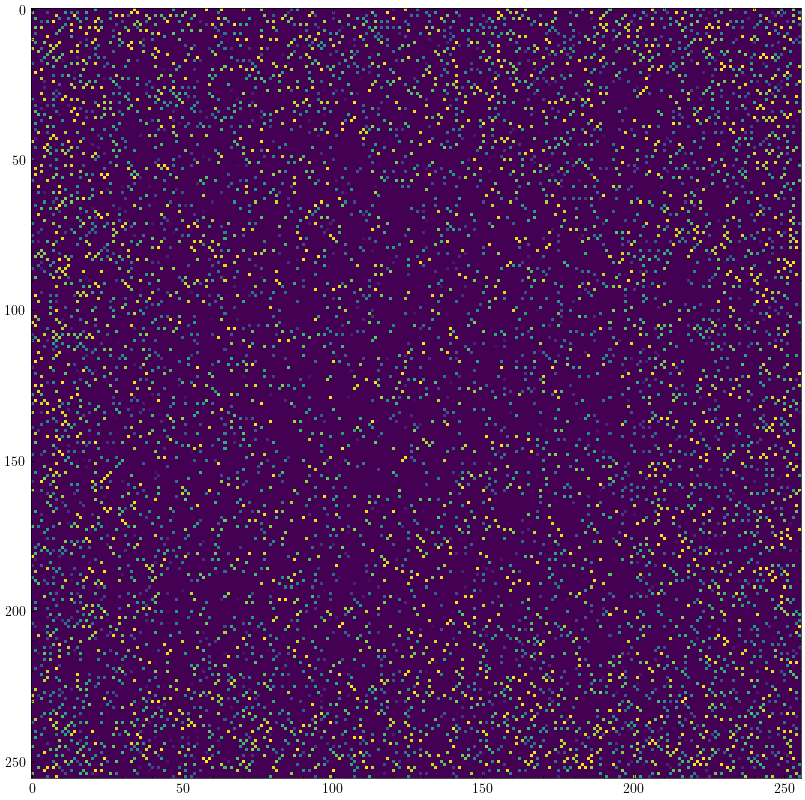

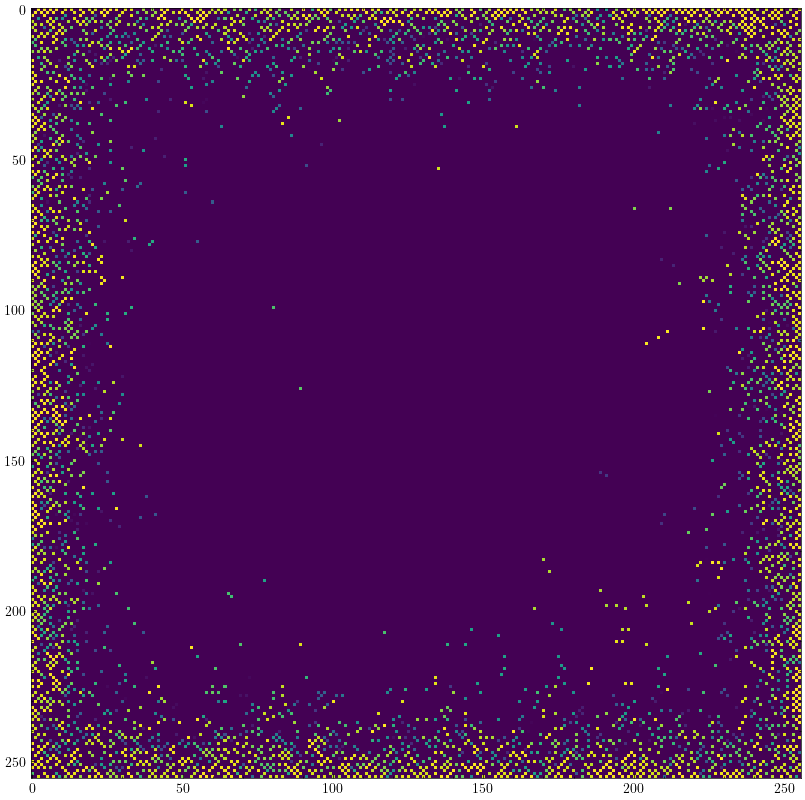

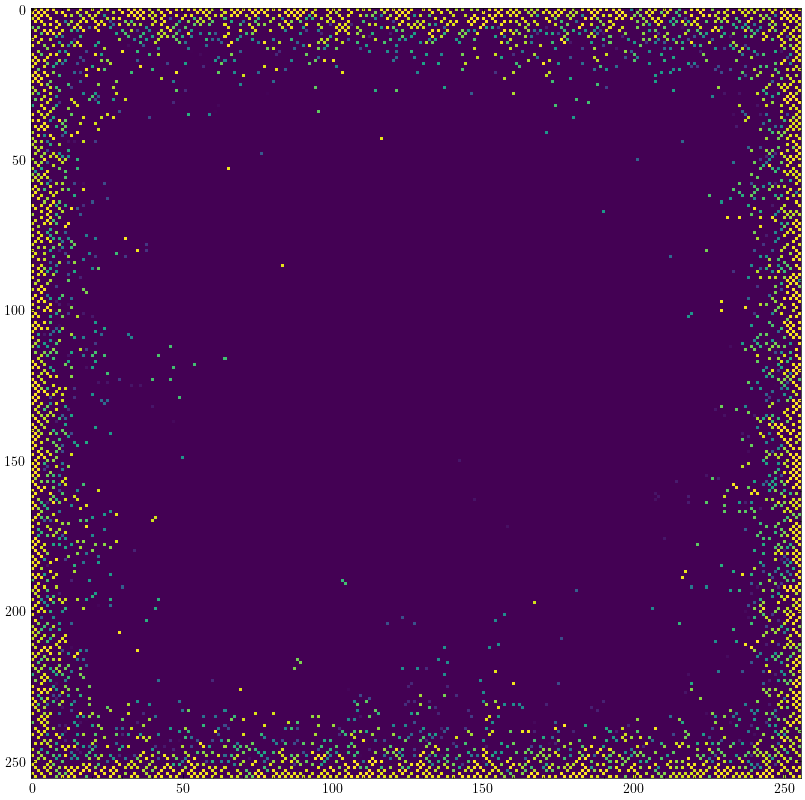

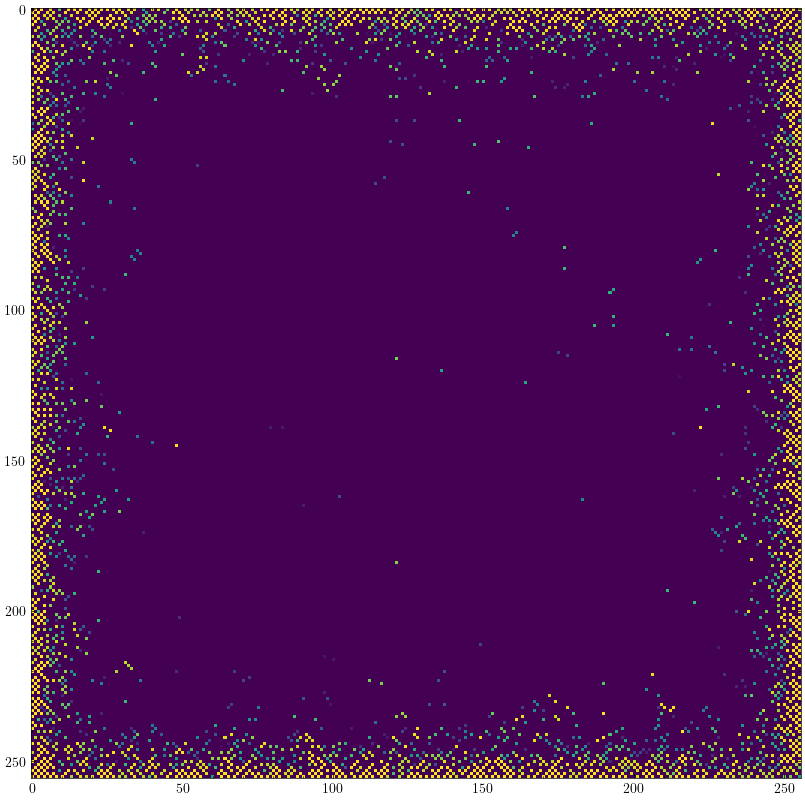

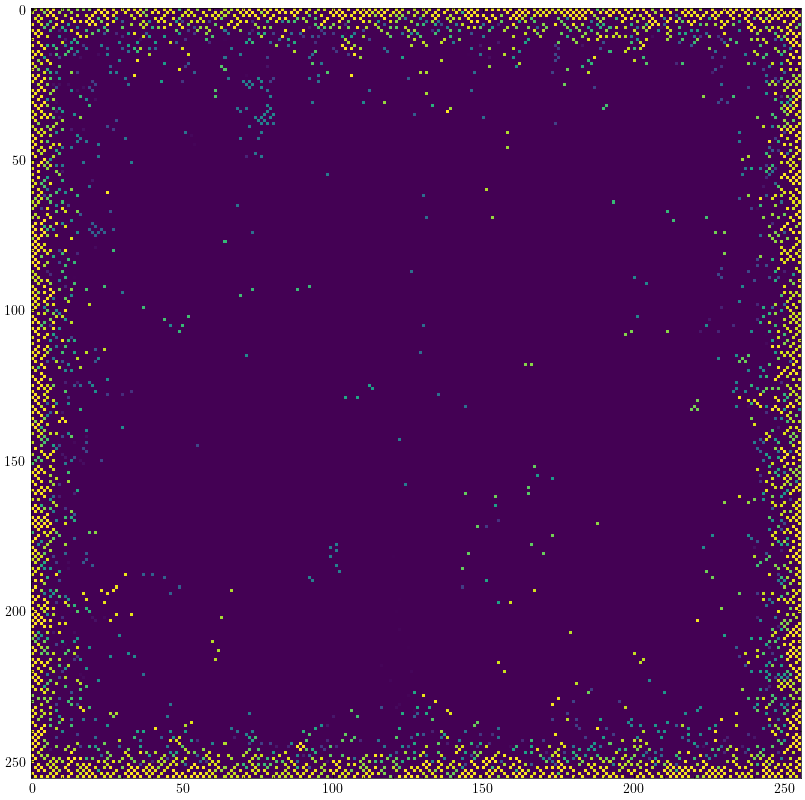

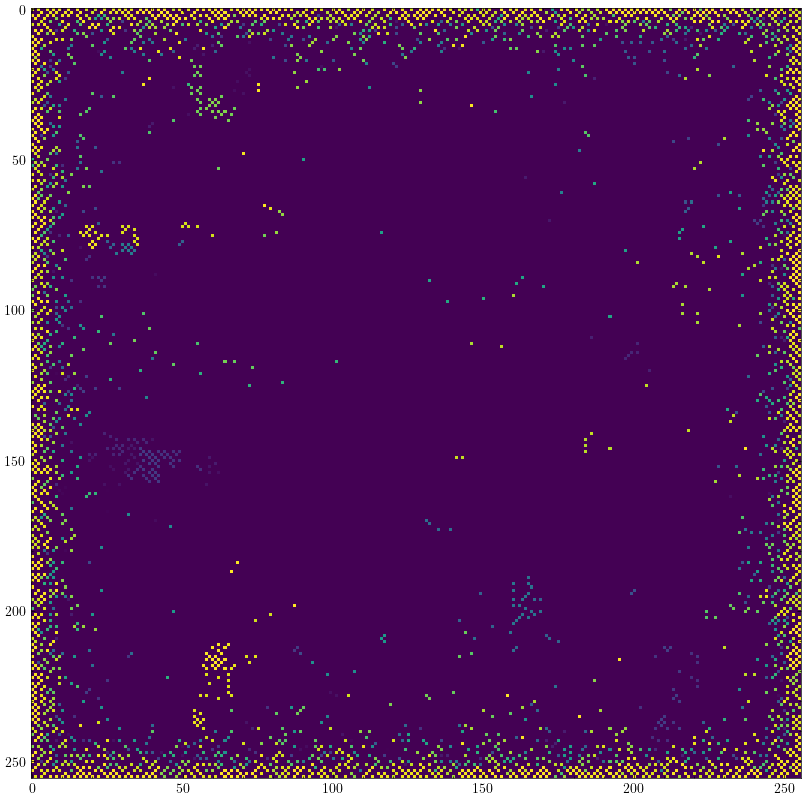

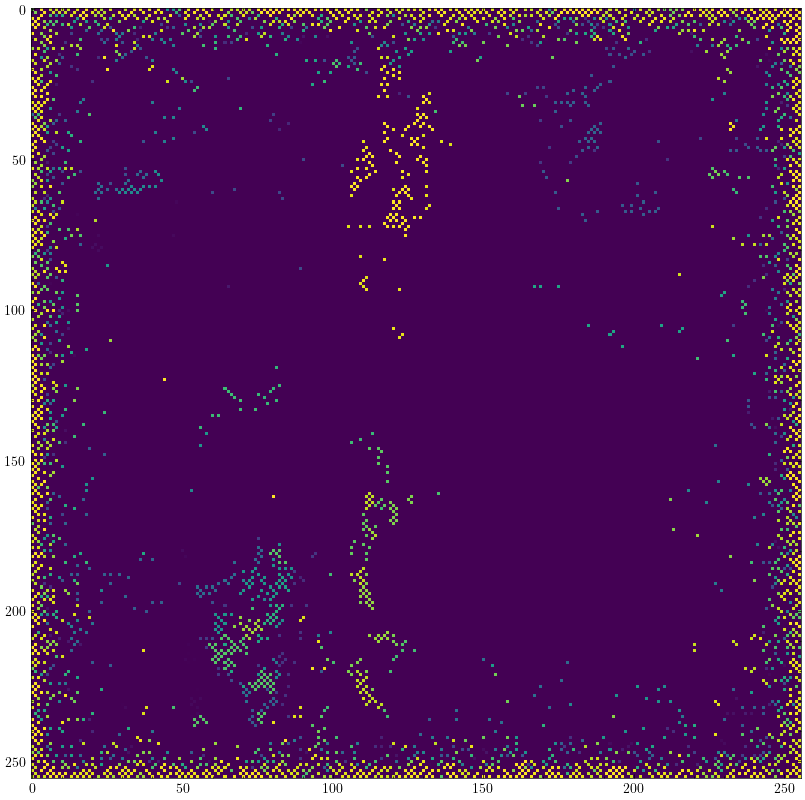

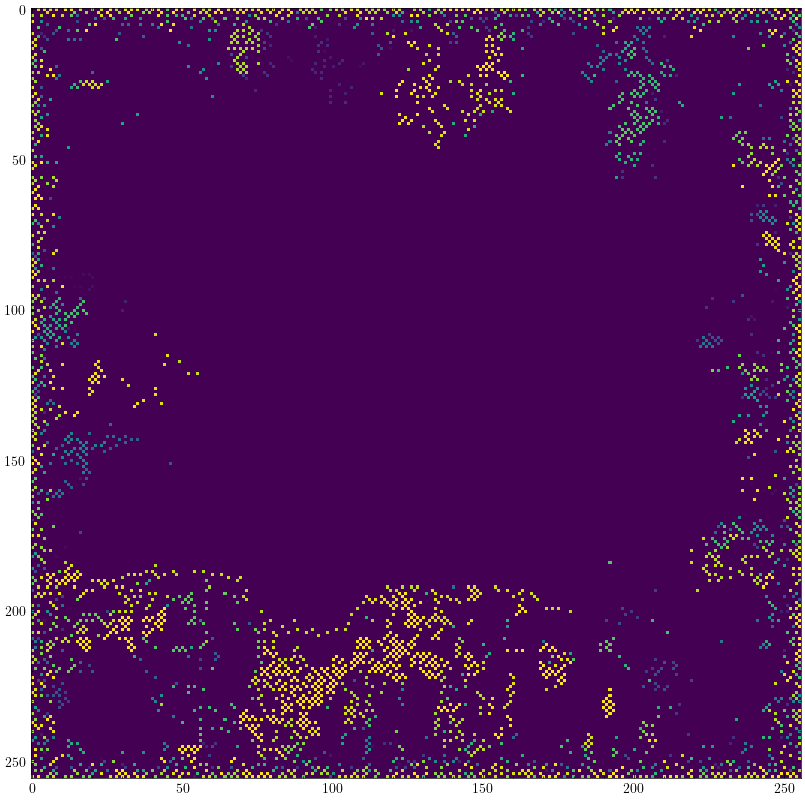

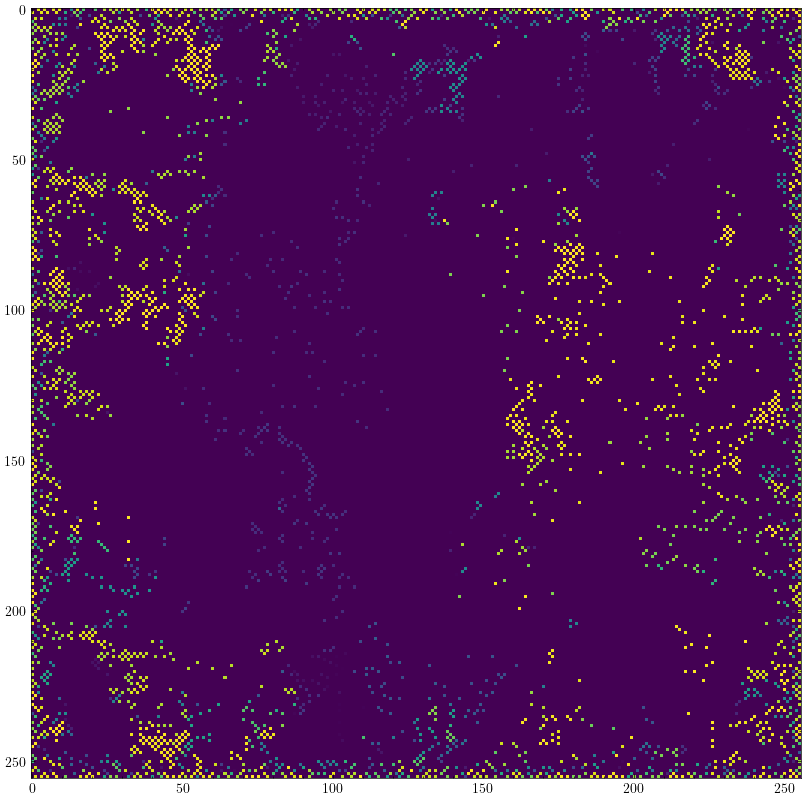

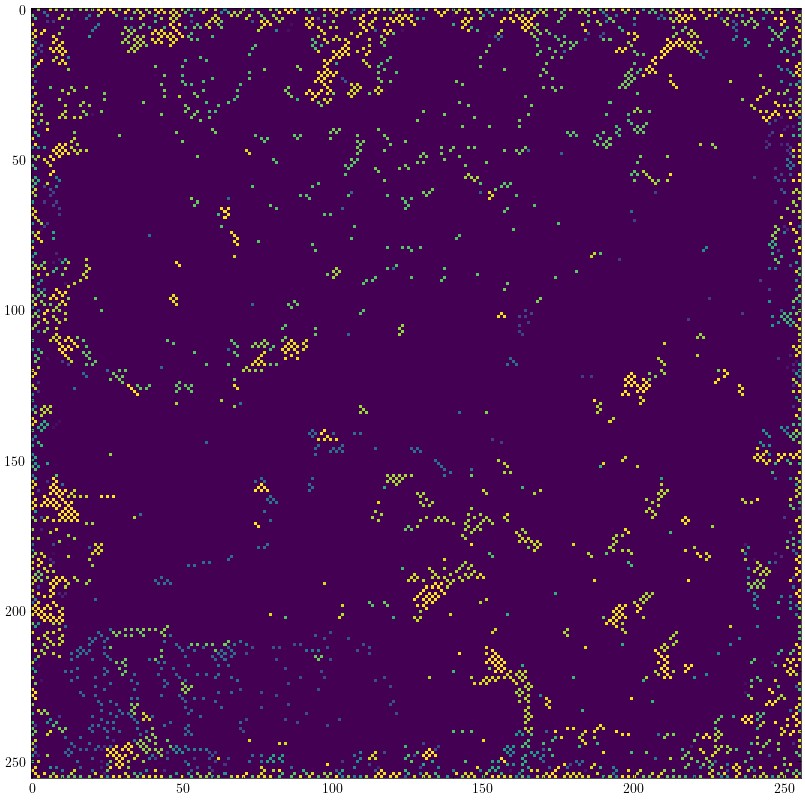

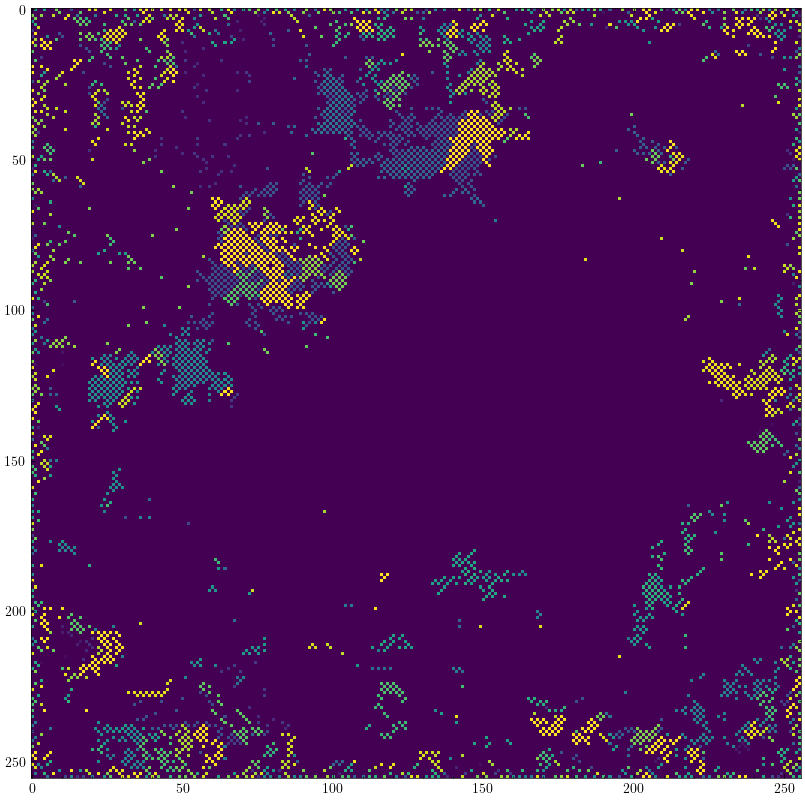

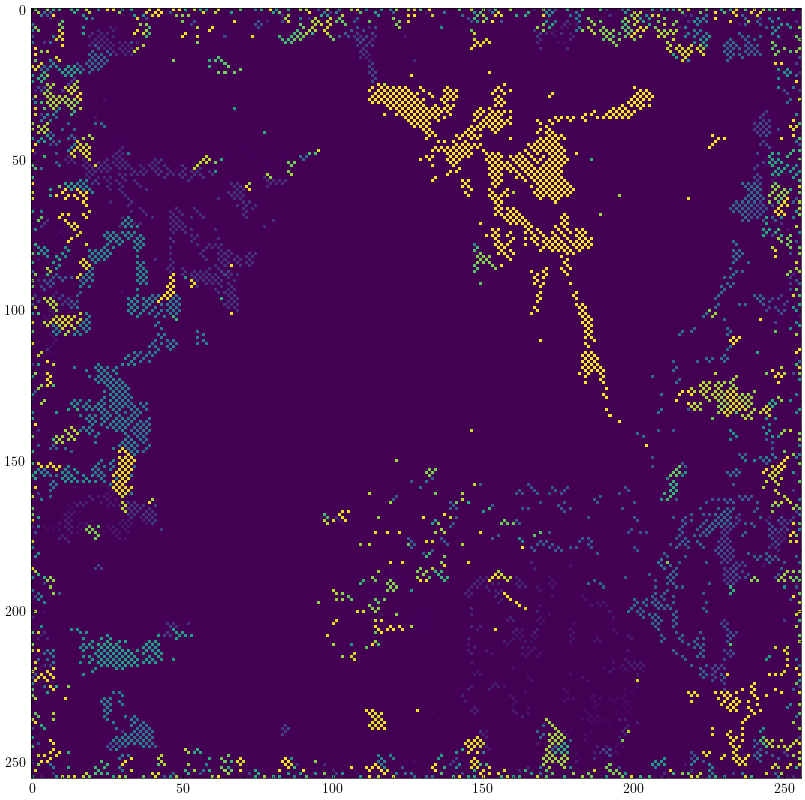

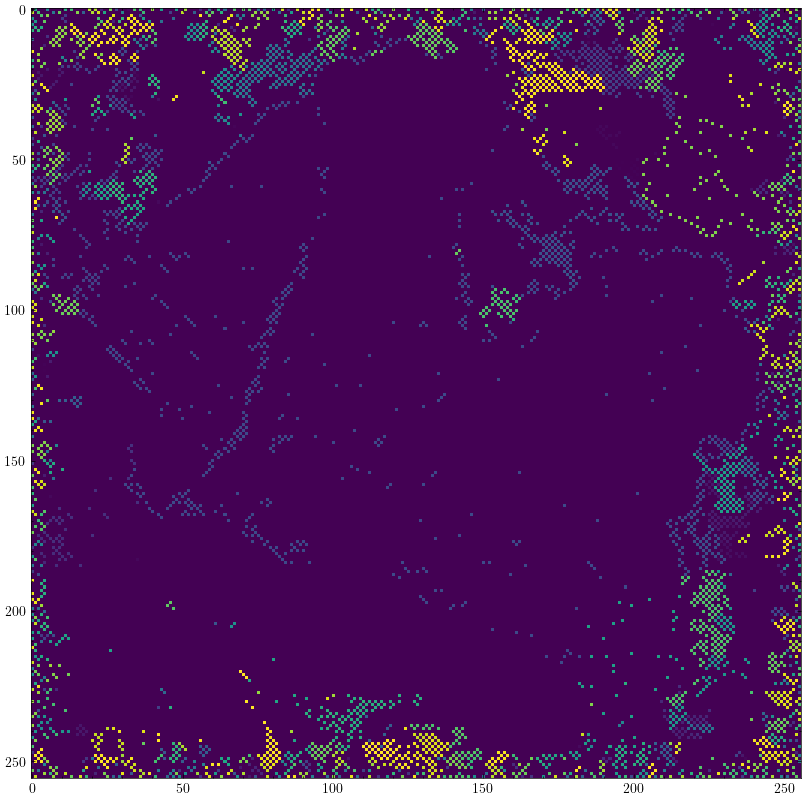

In [ ]:
nrows = 10000
nbfolder = 14
mean_dt = np.zeros(nbfolder)
L1 = 256
L2 = 256
for j in range (1,nbfolder):
    file = "/data1/DATA_Duplat/Brut/PDF/PD12n{}/Avalanche_outputB.gz".format(j)
    
    data = read_gz_with_pandas_nrows(file, nrows, skiprows=1, cols=[2,3])
    nin = np.array(data[:,0], dtype = int)
    dz = data[:,1]
    z = np.cumsum(dz)
    
    y, x = np.unravel_index(nin, (L1,L2))
    
    sys = np.zeros((L1, L2), dtype = float)

    sys[x[0], y[0]] = 1
    dt = np.zeros(nrows)
    for i, (xp, yp) in enumerate(zip(x[1:], y[1:])):
        x_min = max(xp - r, 0)
        x_max = min(xp + r+1, L1) #Avoid to be outside the system
        y_min = max(yp - r, 0)
        y_max = min(yp + r+1, L2)
        subsys = sys[x_min:x_max, y_min:y_max]
        sub_kernel = kernel[(x_min - (xp - r)):(x_max - (xp - r)),(y_min - (yp - r)):(y_max - (yp - r))]

        if (np.sum(subsys[sub_kernel]) == 0):
            # sys[xp,yp] = i+2    #At i = 0, we start at two since the sys is set to 0 and the first com to 1
            sys[xp,yp] = z[i+1]
        else:
            u_val = np.unique(subsys[sub_kernel])
            max_t = np.max(subsys[sub_kernel])
            for val in u_val:
                if val != 0:
                    sys[sys == val] = z[i+1]
            dt[i+1] = z[i+1] - max_t
            

    fig, ax = plt.subplots(figsize = (10,10))
    ax.imshow(sys, cmap = "viridis")
    plt.show()
            
            
    # print(dt, np.mean(dt))
    mean_dt[j-1] = np.mean(dt[dt!=0])

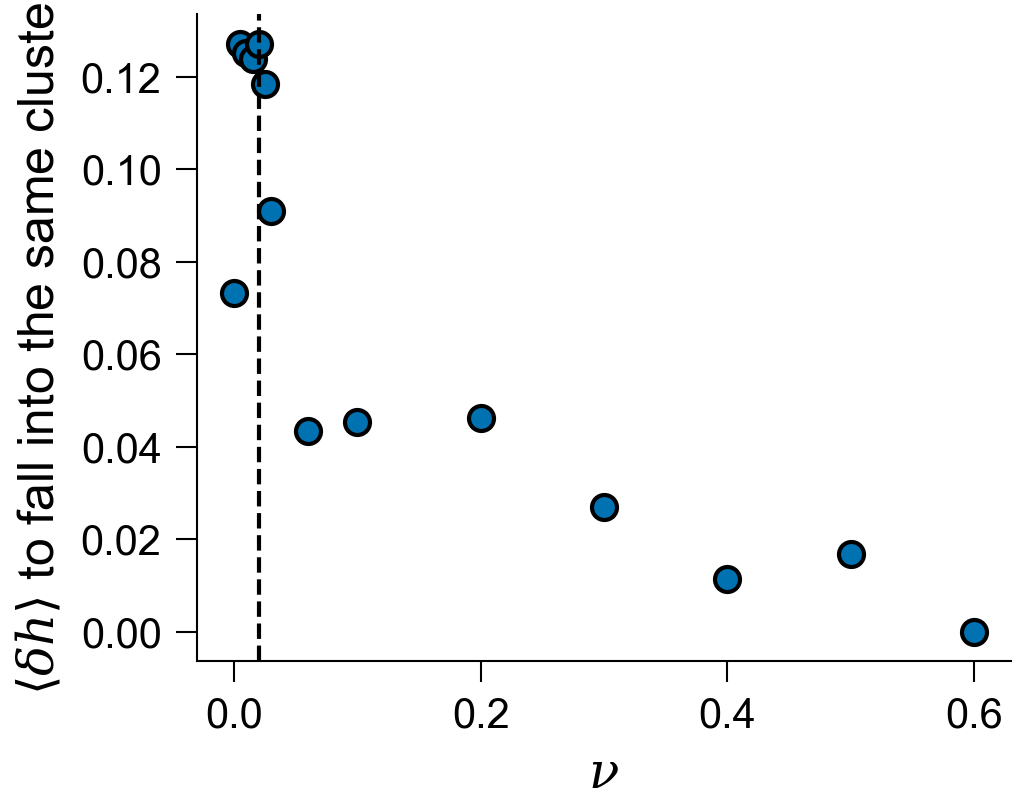

In [9]:
with plt.style.context(spstyle.get_style('thesis')):
    fig, ax = plt.subplots(1, 1, figsize = (3.5,2.8))
    ax.scatter(Tnu, mean_dt, c = color_list[0])
    ax.set_xlabel(r"$\nu$")
    ax.set_ylabel(r"$\langle \delta h \rangle$ to fall into the same cluster")
    ax.axvline(0.02, ls ='--', c ='k')
    
    plt.show()